#0. Import and Config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, make_scorer
)
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
for pkg in ["vader_lexicon", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# ── CONFIGURATION ────────────────────────────────────────────
SEED       = 42
DATA_PATH  = "/content/drive/MyDrive/FakeReviewProject/"
B1_PATH    = DATA_PATH + "experiment_b1/models/"
EXP_PATH   = DATA_PATH + "experiment_b2/"
MODEL_PATH = EXP_PATH  + "models/"

os.makedirs(MODEL_PATH, exist_ok=True)
np.random.seed(SEED)

f1_fake_scorer = make_scorer(f1_score, pos_label=1)

META_COLS = [
    "rating",
    "review_length",
    "extreme_rating",
    "review_month",
    "review_dayofweek",
    "is_weekend",
]

# Behavioral constants (Mohawesh et al. 2023)
EARLY_MONTHS    = 7
B3_THRESH       = 0.69
TOP_RANK_FRAC   = 0.2
BOT_RANK_FRAC   = 0.8
MAX_SIM_REVIEWS = 20
VADER_EXTREME   = 0.5


# ============================================================
# 1. LOAD AND FILTER DATA
# ============================================================

In [3]:
print("=" * 60)
print("1. LOADING AND FILTERING DATA")
print("=" * 60)

df_full = pd.read_csv(DATA_PATH + "yelp_nyc_processed_v2.csv",
                      parse_dates=["review_date"])
df_full = df_full.reset_index(drop=True)
print(f"Unfiltered shape : {df_full.shape}")

# Iterative filtering — identical to B1
print("\nApplying iterative filter (threshold > 3)...")
df = df_full.copy()
iteration = 0
while True:
    n_before = len(df)
    rc = df["reviewer_id"].value_counts()
    df = df[df["reviewer_id"].isin(rc[rc > 3].index)]
    pc = df["product_id"].value_counts()
    df = df[df["product_id"].isin(pc[pc > 3].index)]
    iteration += 1
    n_after = len(df)
    print(f"  Iteration {iteration}: {n_before:,} -> {n_after:,} "
          f"(removed {n_before - n_after:,})")
    if n_after == n_before:
        break

df = df.reset_index(drop=True)

vc = df["label"].value_counts()
print(f"\nFiltered shape : {df.shape}")
print(f"  Genuine (0) : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Fake    (1) : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")
print(f"  Reviewers   : {df['reviewer_id'].nunique():,}")
print(f"  Products    : {df['product_id'].nunique():,}")

required = ["label", "text_clean", "review_date"] + META_COLS
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("Schema check passed")

1. LOADING AND FILTERING DATA
Unfiltered shape : (359052, 13)

Applying iterative filter (threshold > 3)...
  Iteration 1: 359,052 -> 172,395 (removed 186,657)
  Iteration 2: 172,395 -> 172,389 (removed 6)
  Iteration 3: 172,389 -> 172,389 (removed 0)

Filtered shape : (172389, 13)
  Genuine (0) : 167,488 (97.2%)
  Fake    (1) : 4,901 (2.8%)
  Reviewers   : 19,046
  Products    : 918
Schema check passed


# ============================================================
# 2. LOAD B1 SPLIT INDICES
# ============================================================


In [4]:
print("\n" + "=" * 60)
print("2. LOADING B1 SPLIT INDICES")
print("=" * 60)

idx_train = np.load(B1_PATH + "idx_train.npy")
idx_val   = np.load(B1_PATH + "idx_val.npy")
idx_test  = np.load(B1_PATH + "idx_test.npy")

y       = df["label"].values
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

def split_summary(name, y_split):
    n  = len(y_split)
    nf = int(y_split.sum())
    ng = n - nf
    print(f"  {name:12s}: {n:,} | "
          f"Genuine: {ng:,} ({ng/n*100:.1f}%) | "
          f"Fake: {nf:,} ({nf/n*100:.1f}%)")

split_summary("Train",      y_train)
split_summary("Validation", y_val)
split_summary("Test",       y_test)


2. LOADING B1 SPLIT INDICES
  Train       : 120,672 | Genuine: 117,241 (97.2%) | Fake: 3,431 (2.8%)
  Validation  : 25,858 | Genuine: 25,123 (97.2%) | Fake: 735 (2.8%)
  Test        : 25,859 | Genuine: 25,124 (97.2%) | Fake: 735 (2.8%)


# ============================================================
# 3. LOAD CACHED TF-IDF FROM B1
# ============================================================

In [5]:
print("\n" + "=" * 60)
print("3. LOADING CACHED TF-IDF FROM B1")
print("=" * 60)

tfidf         = joblib.load(B1_PATH + "tfidf_vectorizer.pkl")
X_tfidf_train = sp.load_npz(B1_PATH + "X_tfidf_train.npz")
X_tfidf_val   = sp.load_npz(B1_PATH + "X_tfidf_val.npz")
X_tfidf_test  = sp.load_npz(B1_PATH + "X_tfidf_test.npz")

print(f"Loaded train : {X_tfidf_train.shape}")
print(f"Loaded val   : {X_tfidf_val.shape}")
print(f"Loaded test  : {X_tfidf_test.shape}")

# Alignment assertion — confirms B1 and B2 used identical
# filtering and splitting so TF-IDF matrices align correctly
expected_total = (X_tfidf_train.shape[0] +
                  X_tfidf_val.shape[0] +
                  X_tfidf_test.shape[0])
assert len(df) == expected_total, (
    f"TF-IDF alignment error: df has {len(df)} rows but "
    f"TF-IDF splits sum to {expected_total}. "
    f"Ensure B1 and B2 use identical filtering."
)
print("TF-IDF alignment assertion passed")


3. LOADING CACHED TF-IDF FROM B1
Loaded train : (120672, 3000)
Loaded val   : (25858, 3000)
Loaded test  : (25859, 3000)
TF-IDF alignment assertion passed


# ============================================================
# 4. METADATA PREPROCESSING
# ============================================================

In [6]:
print("\n" + "=" * 60)
print("4. METADATA PREPROCESSING")
print("=" * 60)

meta_train_raw = df.iloc[idx_train][META_COLS].values.astype(float)
meta_val_raw   = df.iloc[idx_val][META_COLS].values.astype(float)
meta_test_raw  = df.iloc[idx_test][META_COLS].values.astype(float)

n_null = int(np.isnan(meta_train_raw).sum())
if n_null > 0:
    raise ValueError(f"{n_null} nulls in training metadata.")
print("Null check passed")

meta_scaler = StandardScaler()
meta_train  = meta_scaler.fit_transform(meta_train_raw)
meta_val    = meta_scaler.transform(meta_val_raw)
meta_test   = meta_scaler.transform(meta_test_raw)

joblib.dump(meta_scaler, MODEL_PATH + "meta_scaler.pkl")
print(f"Metadata columns ({len(META_COLS)}): {META_COLS}")


4. METADATA PREPROCESSING
Null check passed
Metadata columns (6): ['rating', 'review_length', 'extreme_rating', 'review_month', 'review_dayofweek', 'is_weekend']


# ============================================================
# 5. BEHAVIORAL FEATURE ENGINEERING
# ============================================================

In [7]:
# LEAKAGE POLICY:
#   All group-level aggregations are computed from TRAINING
#   ROWS ONLY (df_train). Val and test receive these stats
#   via merge. Groups not seen in training receive the global
#   training mean as fallback — this is the standard approach
#   for preventing target/stat leakage in grouped features.
# ============================================================
print("\n" + "=" * 60)
print("5. BEHAVIORAL FEATURE ENGINEERING")
print("=" * 60)

BEHAV_CACHE = MODEL_PATH + "behavioral_features.pkl"

if os.path.exists(BEHAV_CACHE):
    print(f"Loading cached behavioral features...")
    behav_all = joblib.load(BEHAV_CACHE)
    print(f"Loaded: {behav_all.shape}")

else:
    print("Computing behavioral features (first time — will be cached)...")
    print("Expected time: 45-75 min on first run\n")

    # ── Training subset only ──────────────────────────────────
    df_train = df.iloc[idx_train].copy().reset_index(drop=True)
    # Keep original df index so we can merge back later
    df_train["_orig_idx"] = idx_train

    # ── Shared precomputations — FROM TRAIN ONLY ──────────────

    # Product average rating (train only)
    prod_avg_rating_train = (
        df_train.groupby("product_id")["rating"]
                .mean()
                .rename("product_avg_rating")
    )
    global_avg_rating = float(df_train["rating"].mean())

    # Product release date (train only)
    # Defined as date of first review on that product in train
    prod_release_train = (
        df_train.groupby("product_id")["review_date"]
                .min()
                .rename("product_release_date")
    )

    # Product review velocity (train only)
    # Reviews per month since release
    prod_velocity = {}
    for pid, grp in df_train.groupby("product_id"):
        release = grp["review_date"].min()
        latest  = grp["review_date"].max()
        months  = max((latest - release).days / 30.0, 1.0)
        prod_velocity[pid] = len(grp) / months
    global_velocity = float(np.mean(list(prod_velocity.values())))

    # Product rating std (train only)
    prod_rating_std_train = (
        df_train.groupby("product_id")["rating"]
                .std()
                .fillna(0)
                .rename("product_rating_std")
    )
    global_rating_std = float(df_train["rating"].std())

    # Product fake ratio (train only — uses labels)
    # This is the ONLY label-derived feature and MUST be
    # computed from training rows only to prevent leakage.
    prod_fake_ratio_train = (
        df_train.groupby("product_id")["label"]
                .mean()
                .rename("product_fake_ratio")
    )
    global_fake_ratio = float(df_train["label"].mean())

    # Merge precomputed train stats onto full df
    # Val/test groups not seen in train get global mean fallback
    df = df.merge(prod_avg_rating_train,  on="product_id", how="left")
    df = df.merge(prod_release_train,     on="product_id", how="left")
    df = df.merge(prod_rating_std_train,  on="product_id", how="left")
    df = df.merge(prod_fake_ratio_train,  on="product_id", how="left")

    df["product_avg_rating"]  = df["product_avg_rating"].fillna(global_avg_rating)
    df["product_release_date"]= df["product_release_date"].fillna(
        df_train["review_date"].min()
    )
    df["product_rating_std"]  = df["product_rating_std"].fillna(global_rating_std)
    df["product_fake_ratio"]  = df["product_fake_ratio"].fillna(global_fake_ratio)
    df["product_review_velocity"] = (
        df["product_id"].map(prod_velocity).fillna(global_velocity)
    )

    # Chronological rank within product (computed on full df —
    # this uses only dates and product IDs, no labels)
    df["review_rank_in_product"] = (
        df.groupby("product_id")["review_date"]
          .rank(method="first", ascending=True)
    )
    df["reviews_per_product"] = (
        df.groupby("product_id")["product_id"].transform("count")
    )
    df["norm_rank_in_product"] = (
        df["review_rank_in_product"] / df["reviews_per_product"]
    )

    # ── Helper functions ──────────────────────────────────────

    FIRST_PERSON  = frozenset({
        "i","me","my","mine","myself",
        "we","us","our","ours","ourselves"
    })
    SECOND_PERSON = frozenset({
        "you","your","yours","yourself","yourselves"
    })
    THIRD_PERSON  = frozenset({
        "he","him","his","himself","she","her","hers","herself",
        "it","its","itself","they","them","their","theirs","themselves"
    })

    def pronoun_ratios(text):
        if not isinstance(text, str) or len(text.strip()) == 0:
            return 0.0, 0.0, 0.0
        tokens = re.findall(r"\b[a-z]+\b", text.lower())
        n1 = sum(1 for t in tokens if t in FIRST_PERSON)
        n2 = sum(1 for t in tokens if t in SECOND_PERSON)
        n3 = sum(1 for t in tokens if t in THIRD_PERSON)
        total = n1 + n2 + n3
        if total == 0:
            return 0.0, 0.0, 0.0
        return n1/total, n2/total, (n1+n3)/total

    sid = SentimentIntensityAnalyzer()

    def vader_scores(text):
        if not isinstance(text, str) or len(text.strip()) == 0:
            return 0.0, 0.0, 0.0
        score = sid.polarity_scores(text)["compound"]
        return score, 0.0, float(abs(score) > VADER_EXTREME)

    def content_similarity(texts, max_r=MAX_SIM_REVIEWS):
        valid = [t for t in texts
                 if isinstance(t, str) and len(t.strip()) > 0]
        if len(valid) < 2:
            return 0.0, 0.0
        valid = valid[:max_r]
        try:
            tv  = TfidfVectorizer(max_features=200, min_df=1)
            mat = tv.fit_transform(valid)
            n   = mat.shape[0]
            sims = [
                float(cosine_similarity(mat[i], mat[j])[0][0])
                for i in range(n) for j in range(i+1, n)
            ]
            return (float(max(sims)), float(np.mean(sims))
                    ) if sims else (0.0, 0.0)
        except Exception:
            return 0.0, 0.0

    def rating_entropy(ratings):
        counts = np.bincount(
            np.clip(np.array(ratings, dtype=int), 1, 5),
            minlength=6
        )[1:]
        total = counts.sum()
        if total == 0:
            return 0.0
        probs = counts / total
        probs = probs[probs > 0]
        return float(-np.sum(probs * np.log2(probs)))

    # ── Main computation loop ─────────────────────────────────
    def compute_behavioral(df_source, group_col, label=""):
        """
        Compute behavioral features for each unique group.
        df_source: the dataframe to group over (full df after
                   precomputed stats merged in).
        group_col: "reviewer_id" or "product_id"
        """
        suffix      = "_r" if group_col == "reviewer_id" else "_p"
        is_reviewer = (group_col == "reviewer_id")
        groups      = df_source.groupby(group_col)
        n_groups    = len(groups)
        records     = []

        print(f"\n  {label} ({group_col}, {n_groups:,} groups)...")

        for idx_g, (key, grp) in enumerate(groups):
            if idx_g % 3000 == 0:
                print(f"    {idx_g:>6,} / {n_groups:,} "
                      f"({idx_g/n_groups*100:.1f}%)")

            grp      = grp.sort_values("review_date").reset_index(drop=True)
            n        = len(grp)
            ratings  = grp["rating"].values.astype(float)
            dates    = pd.to_datetime(grp["review_date"])
            texts    = grp["text_clean"].fillna("").tolist()
            prod_avg = grp["product_avg_rating"].values.astype(float)

            # F1: ARD
            deviations = np.abs(ratings - prod_avg)
            ARD = float(np.mean(deviations) / 4.0)

            # F2: WRD
            ranks   = np.arange(1, n+1, dtype=float)
            weights = (1.0/ranks) / (1.0/ranks).sum()
            WRD     = float(np.sum(weights * deviations / 4.0))

            # F3: MRD
            MRD = float(np.max(deviations) / 4.0)

            # Burstiness — continuous
            daily_counts        = dates.dt.date.value_counts()
            max_reviews_per_day = int(daily_counts.max())
            if n > 1:
                intervals = np.diff(
                    np.sort(dates.astype(np.int64).values)
                ) / 1e9 / 3600
                mean_iv = float(np.mean(intervals))
                cv = (float(np.std(intervals)) / mean_iv
                      if mean_iv > 0 else 0.0)
            else:
                cv = 0.0

            # F5: ERR
            release_dates = pd.to_datetime(grp["product_release_date"])
            early_count   = 0
            for i in range(n):
                rel = release_dates.iloc[i]
                rev = dates.iloc[i]
                if pd.isnull(rel) or pd.isnull(rev):
                    continue
                months_after = (rev - rel).days / 30.0
                etf  = 1 if months_after <= EARLY_MONTHS else 0
                fetf = 1 if etf > B3_THRESH else 0
                early_count += fetf
            ERR = float(early_count / n)

            # F6: MNR raw
            MNR_raw = float(max_reviews_per_day)

            # F7/F8: RPR / RNR
            RPR = float(np.mean(ratings >= 4))
            RNR = float(np.mean(ratings <= 2))

            # F9: FRR (reviewer only)
            if is_reviewer:
                FRR = float(
                    (grp["review_rank_in_product"] == 1).sum() / n
                )

            # F10: EXRR
            EXRR = float(np.mean((ratings == 1) | (ratings == 5)))

            # F11/F13: TRRR / BRRR
            nrp  = grp["norm_rank_in_product"].values
            TRRR = float(np.mean(nrp <= TOP_RANK_FRAC))
            BRRR = float(np.mean(nrp >= BOT_RANK_FRAC))

            # F15/F16: MCS / ACS
            MCS, ACS = content_similarity(texts)

            # Pronoun ratios (ASAPP dropped — identical to ASPPR)
            pron   = [pronoun_ratios(t) for t in texts]
            AFPPR  = float(np.mean([r[0] for r in pron]))
            ASPPR  = float(np.mean([r[1] for r in pron]))
            AFTAPP = float(np.mean([r[2] for r in pron]))

            # VADER sentiment
            vader                = [vader_scores(t) for t in texts]
            vader_compound_mean  = float(np.mean([v[0] for v in vader]))
            vader_compound_std   = float(np.std( [v[0] for v in vader]))
            vader_extreme_ratio  = float(np.mean([v[2] for v in vader]))

            # Avg word count (continuous — replaces binary ARL)
            avg_word_count = float(
                np.mean([len(t.split()) for t in texts])
            )

            # Additional features
            reviewer_avg_rating = float(np.mean(ratings))
            r_entropy           = rating_entropy(ratings.astype(int))
            review_count        = float(n)

            record = {
                group_col:                        key,
                f"ARD{suffix}":                   ARD,
                f"WRD{suffix}":                   WRD,
                f"MRD{suffix}":                   MRD,
                f"max_reviews_per_day{suffix}":   float(max_reviews_per_day),
                f"review_interval_cv{suffix}":    cv,
                f"ERR{suffix}":                   ERR,
                f"MNR_raw{suffix}":               MNR_raw,
                f"RPR{suffix}":                   RPR,
                f"RNR{suffix}":                   RNR,
                f"EXRR{suffix}":                  EXRR,
                f"TRRR{suffix}":                  TRRR,
                f"BRRR{suffix}":                  BRRR,
                f"MCS{suffix}":                   MCS,
                f"ACS{suffix}":                   ACS,
                f"AFPPR{suffix}":                 AFPPR,
                f"ASPPR{suffix}":                 ASPPR,
                f"AFTAPP{suffix}":                AFTAPP,
                f"vader_compound_mean{suffix}":   vader_compound_mean,
                f"vader_compound_std{suffix}":    vader_compound_std,
                f"vader_extreme_ratio{suffix}":   vader_extreme_ratio,
                f"avg_word_count{suffix}":        avg_word_count,
                f"reviewer_avg_rating{suffix}":   reviewer_avg_rating,
                f"rating_entropy{suffix}":        r_entropy,
                f"review_count{suffix}":          review_count,
            }

            if is_reviewer:
                # Fraction of products reviewed only once
                pv_counts  = grp["product_id"].value_counts()
                pct_single = float((pv_counts == 1).sum()
                                   / len(pv_counts))
                weekend_ratio = float(grp["is_weekend"].mean()
                    if "is_weekend" in grp.columns else 0.0)
                unique_products_ratio = float(
                    grp["product_id"].nunique() / n
                )
                record[f"FRR{suffix}"]                        = FRR
                record[f"pct_single_review_products{suffix}"] = pct_single
                record[f"weekend_ratio{suffix}"]              = weekend_ratio
                record[f"unique_products_ratio{suffix}"]      = unique_products_ratio

            records.append(record)

        feat_df = pd.DataFrame(records)

        # Normalise MNR by global max within this group set
        raw_col   = f"MNR_raw{suffix}"
        final_col = f"MNR{suffix}"
        gmax = feat_df[raw_col].max()
        feat_df[final_col] = (
            feat_df[raw_col] / gmax if gmax > 0 else 0.0
        )
        feat_df = feat_df.drop(columns=[raw_col])
        print(f"  Done. Shape: {feat_df.shape}")
        return feat_df

    # Compute features
    reviewer_features = compute_behavioral(
        df, "reviewer_id", "Reviewer-level features"
    )
    product_features  = compute_behavioral(
        df, "product_id", "Product-level features"
    )

    # Add product-specific columns to product features
    # These were computed from train only and merged into df above
    prod_extra = df.groupby("product_id").first()[
        ["product_review_velocity",
         "product_rating_std",
         "product_fake_ratio"]
    ].reset_index()
    product_features = product_features.merge(
        prod_extra, on="product_id", how="left"
    )

    # ── Merge back to review level ────────────────────────────
    print("\nMerging features to review level...")
    behav_df = df[["reviewer_id", "product_id"]].copy()
    behav_df = behav_df.merge(reviewer_features,
                               on="reviewer_id", how="left")
    behav_df = behav_df.merge(product_features,
                               on="product_id",  how="left")
    behav_df = behav_df.drop(
        columns=["reviewer_id", "product_id"], errors="ignore"
    )

    # Fill residual nulls with 0
    n_null = int(behav_df.isnull().sum().sum())
    if n_null > 0:
        print(f"  Filling {n_null} residual nulls with 0")
        behav_df = behav_df.fillna(0.0)

    # Sanity check
    arr = behav_df.values.astype(float)
    assert np.isfinite(arr).all(), \
        "Non-finite values in behavioral features"
    print(f"  Sanity check passed: no inf/nan")
    print(f"  Behavioral features shape: {behav_df.shape}")

    # Cache
    joblib.dump(behav_df, BEHAV_CACHE)
    print(f"\nCached to: {BEHAV_CACHE}")

    # Clean up helper columns from df
    for col in ["product_avg_rating", "product_release_date",
                "product_rating_std", "product_fake_ratio",
                "product_review_velocity",
                "review_rank_in_product", "reviews_per_product",
                "norm_rank_in_product"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

# ── Split behavioral features ─────────────────────────────────
behav_cols  = list(behav_df.columns)
print(f"\nBehavioral feature columns ({len(behav_cols)}):")
print(behav_cols)

behav_train = behav_df.iloc[idx_train].values.astype(float)
behav_val   = behav_df.iloc[idx_val].values.astype(float)
behav_test  = behav_df.iloc[idx_test].values.astype(float)

# Scale behavioral features — needed for LR
behav_scaler = StandardScaler()
behav_train  = behav_scaler.fit_transform(behav_train)
behav_val    = behav_scaler.transform(behav_val)
behav_test   = behav_scaler.transform(behav_test)

joblib.dump(behav_scaler, MODEL_PATH + "behav_scaler.pkl")
print("Saved: behav_scaler.pkl")


5. BEHAVIORAL FEATURE ENGINEERING
Computing behavioral features (first time — will be cached)...
Expected time: 45-75 min on first run


  Reviewer-level features (reviewer_id, 19,046 groups)...
         0 / 19,046 (0.0%)
     3,000 / 19,046 (15.8%)
     6,000 / 19,046 (31.5%)
     9,000 / 19,046 (47.3%)
    12,000 / 19,046 (63.0%)
    15,000 / 19,046 (78.8%)
    18,000 / 19,046 (94.5%)
  Done. Shape: (19046, 29)

  Product-level features (product_id, 918 groups)...
         0 / 918 (0.0%)
  Done. Shape: (918, 25)

Merging features to review level...
  Sanity check passed: no inf/nan
  Behavioral features shape: (172389, 55)

Cached to: /content/drive/MyDrive/FakeReviewProject/experiment_b2/models/behavioral_features.pkl

Behavioral feature columns (55):
['ARD_r', 'WRD_r', 'MRD_r', 'max_reviews_per_day_r', 'review_interval_cv_r', 'ERR_r', 'RPR_r', 'RNR_r', 'EXRR_r', 'TRRR_r', 'BRRR_r', 'MCS_r', 'ACS_r', 'AFPPR_r', 'ASPPR_r', 'AFTAPP_r', 'vader_compound_mean_r', 'vader_compound_std_r',

# ============================================================
# 6. ASSEMBLE FEATURE MATRICES
# ============================================================

In [8]:
print("\n" + "=" * 60)
print("6. ASSEMBLING FEATURE MATRICES")
print("=" * 60)

meta_train_sp  = sp.csr_matrix(meta_train)
meta_val_sp    = sp.csr_matrix(meta_val)
meta_test_sp   = sp.csr_matrix(meta_test)
behav_train_sp = sp.csr_matrix(behav_train)
behav_val_sp   = sp.csr_matrix(behav_val)
behav_test_sp  = sp.csr_matrix(behav_test)

X_train = sp.hstack(
    [X_tfidf_train, meta_train_sp, behav_train_sp], format="csr"
)
X_val   = sp.hstack(
    [X_tfidf_val,   meta_val_sp,   behav_val_sp],   format="csr"
)
X_test  = sp.hstack(
    [X_tfidf_test,  meta_test_sp,  behav_test_sp],  format="csr"
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"  TF-IDF     : {X_tfidf_train.shape[1]}")
print(f"  Metadata   : {len(META_COLS)}")
print(f"  Behavioral : {len(behav_cols)}")
print(f"  Total      : {X_train.shape[1]}")

feature_names = (
    tfidf.get_feature_names_out().tolist() +
    META_COLS +
    behav_cols
)
joblib.dump(feature_names, MODEL_PATH + "feature_names.pkl")
print("Saved: feature_names.pkl")



6. ASSEMBLING FEATURE MATRICES
X_train : (120672, 3061)
X_val   : (25858, 3061)
X_test  : (25859, 3061)
  TF-IDF     : 3000
  Metadata   : 6
  Behavioral : 55
  Total      : 3061
Saved: feature_names.pkl


# ============================================================
# 7. CLASS IMBALANCE RATIO
# ============================================================

In [9]:
n_genuine_train  = int((y_train == 0).sum())
n_fake_train     = int((y_train == 1).sum())
scale_pos_weight = n_genuine_train / n_fake_train

print(f"\nClass imbalance (train only):")
print(f"  Genuine : {n_genuine_train:,}")
print(f"  Fake    : {n_fake_train:,}")
print(f"  Ratio   : {scale_pos_weight:.4f}")


Class imbalance (train only):
  Genuine : 117,241
  Fake    : 3,431
  Ratio   : 34.1711


# ============================================================
# 8. EVALUATION HELPERS
# ============================================================

In [10]:
def get_metrics(y_true, y_pred, y_proba, name, threshold):
    p_gen       = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    r_gen       = recall_score(   y_true, y_pred, pos_label=0, zero_division=0)
    f1_gen      = f1_score(       y_true, y_pred, pos_label=0, zero_division=0)
    p_fake      = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r_fake      = recall_score(   y_true, y_pred, pos_label=1, zero_division=0)
    f1_fake     = f1_score(       y_true, y_pred, pos_label=1, zero_division=0)
    acc         = float((y_true == y_pred).mean())
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc         = roc_auc_score(y_true, y_proba)
    prauc       = average_precision_score(y_true, y_proba)
    return {
        "model":          name,
        "threshold":      round(threshold,    3),
        "accuracy":       round(acc,          4),
        "f1_macro":       round(f1_macro,     4),
        "f1_weighted":    round(f1_weighted,  4),
        "roc_auc":        round(auc,          4),
        "pr_auc":         round(prauc,        4),
        "precision_gen":  round(p_gen,        4),
        "recall_gen":     round(r_gen,        4),
        "f1_gen":         round(f1_gen,       4),
        "precision_fake": round(p_fake,       4),
        "recall_fake":    round(r_fake,       4),
        "f1_fake":        round(f1_fake,      4),
    }

def print_evaluation(y_true, y_pred, y_proba, name, threshold):
    metrics = get_metrics(y_true, y_pred, y_proba, name, threshold)
    print(f"\n{'─' * 55}")
    print(f"  {name}  (threshold = {threshold:.3f})")
    print(f"{'─' * 55}")
    print(f"  -- Overall --")
    print(f"  Accuracy         : {metrics['accuracy']:.4f}")
    print(f"  F1 macro         : {metrics['f1_macro']:.4f}")
    print(f"  F1 weighted      : {metrics['f1_weighted']:.4f}")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC           : {metrics['pr_auc']:.4f}")
    print(f"  -- Genuine class --")
    print(f"  Precision        : {metrics['precision_gen']:.4f}")
    print(f"  Recall           : {metrics['recall_gen']:.4f}")
    print(f"  F1-score         : {metrics['f1_gen']:.4f}")
    print(f"  -- Fake class --")
    print(f"  Precision        : {metrics['precision_fake']:.4f}")
    print(f"  Recall           : {metrics['recall_fake']:.4f}")
    print(f"  F1-score         : {metrics['f1_fake']:.4f}")
    print(f"\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Genuine (0)", "Fake (1)"],
        digits=4
    ))
    return metrics

def plot_confusion(y_true, y_pred, name, save_path):
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Genuine", "Fake"],
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}", fontsize=10, fontweight="bold")
    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"confusion_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_pr_curve(y_true, y_proba, name, save_path):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    prauc = average_precision_score(y_true, y_proba)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(rec, prec, color="steelblue", lw=2,
            label=f"PR-AUC = {prauc:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"PR Curve — {name}", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    fname = name.lower().replace(" ", "_")
    plt.savefig(save_path + f"pr_curve_{fname}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

def tune_threshold(y_true, y_proba, model_name):
    """
    Find threshold maximising fake-class F1 on validation set.
    Sweeps linspace(0.05, 0.95, 500) — avoids noisy extremes.
    Never call on test set.
    """
    thresholds      = np.linspace(0.05, 0.95, 500)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        f1_t     = f1_score(y_true, y_pred_t,
                            pos_label=1, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_t  = t
    print(f"\n  Threshold tuning ({model_name}):")
    print(f"    Search range   : 0.05 -> 0.95 (500 steps)")
    print(f"    Best threshold : {best_t:.4f}")
    print(f"    Best val F1    : {best_f1:.4f}")
    return float(best_t), float(best_f1)


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================


9. LOGISTIC REGRESSION
Grid search: C in [0.1, 0.5, 1.0]
3-fold CV x 3 values = 9 fits...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Grid search results:
  C=0.10 -> CV F1=0.1806 (+/-0.0015)
  C=0.50 -> CV F1=0.1809 (+/-0.0028)
  C=1.00 -> CV F1=0.1769 (+/-0.0031)

Best params : {'C': 0.5}
Best CV F1  : 0.1809
Saved: logistic_regression.pkl

  Threshold tuning (Logistic Regression):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.8797
    Best val F1    : 0.2337

Validation performance (for reference only):

───────────────────────────────────────────────────────
  LR — validation  (threshold = 0.880)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.9500
  F1 macro         : 0.6039
  F1 weighted      : 0.9531
  ROC-AUC          : 0.8245
  PR-AUC           : 0.1548
  -- Genuine class --
  Precision        : 0.9784
  Recall           : 0.9700
  F1-score         : 0.9742
  -- Fake class --
  Precision    

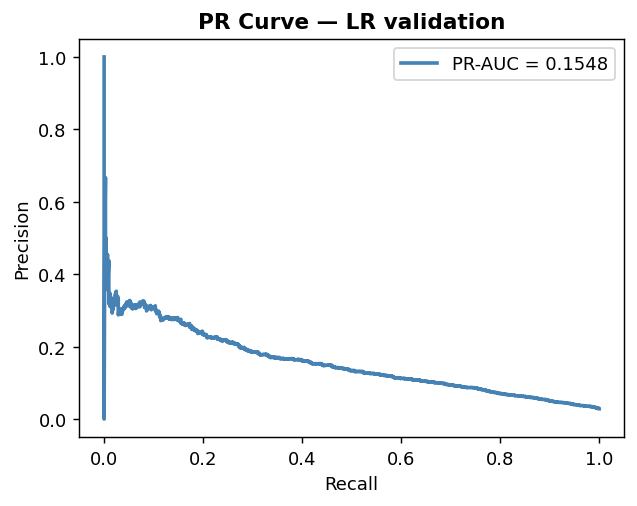

In [11]:
print("\n" + "=" * 60)
print("9. LOGISTIC REGRESSION")
print("=" * 60)

lr_param_grid = {"C": [0.1, 0.5, 1.0]}
print(f"Grid search: C in {lr_param_grid['C']}")
print("3-fold CV x 3 values = 9 fits...")

lr_gs = GridSearchCV(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=SEED
    ),
    param_grid=lr_param_grid,
    scoring=f1_fake_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True
)
lr_gs.fit(X_train, y_train)

print(f"\nGrid search results:")
cv_df = pd.DataFrame(lr_gs.cv_results_)
for _, row in cv_df[["param_C", "mean_test_score",
                       "std_test_score"]].iterrows():
    print(f"  C={row['param_C']:.2f} -> "
          f"CV F1={row['mean_test_score']:.4f} "
          f"(+/-{row['std_test_score']:.4f})")

print(f"\nBest params : {lr_gs.best_params_}")
print(f"Best CV F1  : {lr_gs.best_score_:.4f}")

best_lr = lr_gs.best_estimator_
joblib.dump(best_lr, MODEL_PATH + "logistic_regression.pkl")
print("Saved: logistic_regression.pkl")

lr_val_proba         = best_lr.predict_proba(X_val)[:, 1]
lr_thresh, lr_val_f1 = tune_threshold(y_val, lr_val_proba,
                                       "Logistic Regression")
lr_val_pred = (lr_val_proba >= lr_thresh).astype(int)
print("\nValidation performance (for reference only):")
val_metrics_lr = print_evaluation(
    y_val, lr_val_pred, lr_val_proba,
    "LR — validation", lr_thresh
)
plot_pr_curve(y_val, lr_val_proba, "LR validation", MODEL_PATH)

# ============================================================
# 10. LIGHTGBM
# ============================================================


10. LIGHTGBM
Grid: {'num_leaves': [31, 64, 128], 'learning_rate': [0.05, 0.1], 'min_child_samples': [20, 50], 'reg_lambda': [0, 1]}
Total combinations: 24

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=20,rl=0)):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.6416
    Best val F1    : 0.6311
  nl= 31 lr=0.05 mcs=20 rl=0 | iter= 999 | val F1=0.6311

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=20,rl=1)):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.6001
    Best val F1    : 0.6580
  nl= 31 lr=0.05 mcs=20 rl=1 | iter=1000 | val F1=0.6580

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=50,rl=0)):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.5893
    Best val F1    : 0.6232
  nl= 31 lr=0.05 mcs=50 rl=0 | iter= 997 | val F1=0.6232

  Threshold tuning (LGBM(nl=31,lr=0.05,mcs=50,rl=1)):
    Search range   : 0.05 -> 0.95 (500 steps)
    Best threshold : 0.6217
    Best val F1    : 0.6478
  nl= 31 lr=0.05 mcs=50 rl=1 | iter=1000 | va

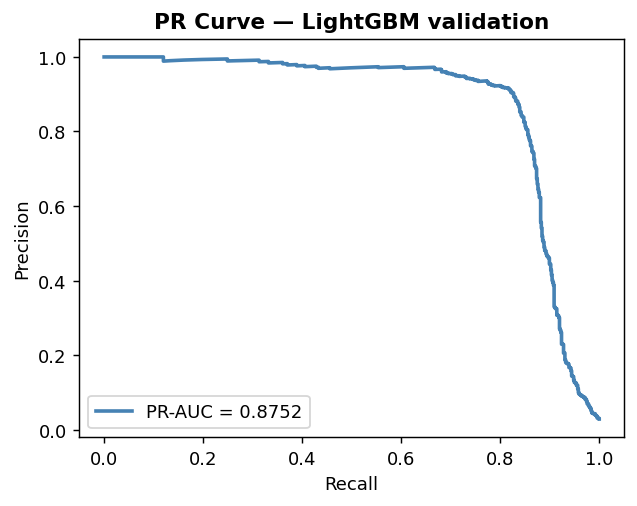

In [12]:
print("\n" + "=" * 60)
print("10. LIGHTGBM")
print("=" * 60)

# Expanded grid — adds min_child_samples and reg_lambda
# which are important for small imbalanced datasets.
# min_child_samples: min samples in a leaf — prevents overfitting
#   on the small fake class (only ~3.4k training fakes)
# reg_lambda: L2 regularisation — improves generalisation
# Total: 3 x 2 x 2 x 2 = 24 combinations
lgbm_grid = {
    "num_leaves":        [31, 64, 128],
    "learning_rate":     [0.05, 0.1],
    "min_child_samples": [20, 50],
    "reg_lambda":        [0, 1],
}

n_combos = (len(lgbm_grid["num_leaves"]) *
            len(lgbm_grid["learning_rate"]) *
            len(lgbm_grid["min_child_samples"]) *
            len(lgbm_grid["reg_lambda"]))
print(f"Grid: {lgbm_grid}")
print(f"Total combinations: {n_combos}")

best_lgbm_val_f1  = 0.0
best_lgbm_params  = {}
best_lgbm         = None
best_lgbm_thresh  = 0.5
lgbm_grid_results = []

for nl in lgbm_grid["num_leaves"]:
    for lr_val in lgbm_grid["learning_rate"]:
        for mcs in lgbm_grid["min_child_samples"]:
            for rl in lgbm_grid["reg_lambda"]:

                candidate = lgb.LGBMClassifier(
                    n_estimators=1000,
                    learning_rate=lr_val,
                    max_depth=-1,
                    num_leaves=nl,
                    min_child_samples=mcs,
                    reg_lambda=rl,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=scale_pos_weight,
                    metric="auc",
                    random_state=SEED,
                    n_jobs=-1,
                    verbose=-1
                )
                candidate.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[
                        lgb.early_stopping(
                            stopping_rounds=100, verbose=False
                        ),
                        lgb.log_evaluation(period=-1)
                    ]
                )

                val_proba = candidate.predict_proba(X_val)[:, 1]
                cand_thresh, cand_f1 = tune_threshold(
                    y_val, val_proba,
                    f"LGBM(nl={nl},lr={lr_val},"
                    f"mcs={mcs},rl={rl})"
                )
                print(f"  nl={nl:3d} lr={lr_val:.2f} "
                      f"mcs={mcs:2d} rl={rl} | "
                      f"iter={candidate.best_iteration_:4d} | "
                      f"val F1={cand_f1:.4f}")

                lgbm_grid_results.append({
                    "num_leaves":        nl,
                    "learning_rate":     lr_val,
                    "min_child_samples": mcs,
                    "reg_lambda":        rl,
                    "best_iter":         candidate.best_iteration_,
                    "val_f1":            round(cand_f1,     4),
                    "threshold":         round(cand_thresh, 4),
                })

                if cand_f1 > best_lgbm_val_f1:
                    best_lgbm_val_f1 = cand_f1
                    best_lgbm_params = {
                        "num_leaves":        nl,
                        "learning_rate":     lr_val,
                        "min_child_samples": mcs,
                        "reg_lambda":        rl,
                    }
                    best_lgbm        = candidate
                    best_lgbm_thresh = cand_thresh

print(f"\nBest LGBM params : {best_lgbm_params}")
print(f"Best LGBM val F1 : {best_lgbm_val_f1:.4f}")
print(f"Best threshold   : {best_lgbm_thresh:.4f}")

lgbm_grid_df = pd.DataFrame(lgbm_grid_results)
print("\nFull grid results:")
print(lgbm_grid_df.to_string(index=False))

joblib.dump(best_lgbm, MODEL_PATH + "lightgbm.pkl")
print("\nSaved: lightgbm.pkl")

lgbm_val_proba = best_lgbm.predict_proba(X_val)[:, 1]
lgbm_val_pred  = (lgbm_val_proba >= best_lgbm_thresh).astype(int)
print("\nValidation performance (for reference only):")
val_metrics_lgbm = print_evaluation(
    y_val, lgbm_val_pred, lgbm_val_proba,
    "LightGBM — validation", best_lgbm_thresh
)
plot_pr_curve(y_val, lgbm_val_proba,
              "LightGBM validation", MODEL_PATH)

In [13]:
# ── LEAKAGE DIAGNOSTIC ───────────────────────────────────────
print("LEAKAGE DIAGNOSTIC")
print("=" * 50)

# Check 1: product_fake_ratio distribution
# In a clean setup, val/test rows should show
# the global training mean for unseen products
pfr_col = "product_fake_ratio_p" if "product_fake_ratio_p" \
           in behav_df.columns else None

if pfr_col:
    pfr_train = behav_df.iloc[idx_train][pfr_col]
    pfr_val   = behav_df.iloc[idx_val][pfr_col]
    pfr_test  = behav_df.iloc[idx_test][pfr_col]
    print(f"\nproduct_fake_ratio mean:")
    print(f"  Train : {pfr_train.mean():.4f}")
    print(f"  Val   : {pfr_val.mean():.4f}")
    print(f"  Test  : {pfr_test.mean():.4f}")
    print(f"  (if val/test >> train mean, leakage likely)")

# Check 2: permutation test — shuffle labels and check val F1
# A leaky model maintains high F1 even with shuffled labels
# because features encode label info directly
from sklearn.metrics import f1_score
import numpy as np

np.random.seed(42)
y_val_shuffled = y_val.copy()
np.random.shuffle(y_val_shuffled)

lgbm_val_proba = best_lgbm.predict_proba(X_val)[:, 1]
lgbm_val_pred  = (lgbm_val_proba >= best_lgbm_thresh).astype(int)

# What F1 do we get if we evaluate against SHUFFLED labels?
f1_shuffled = f1_score(y_val_shuffled, lgbm_val_pred,
                        pos_label=1, zero_division=0)
f1_real     = f1_score(y_val, lgbm_val_pred,
                        pos_label=1, zero_division=0)
print(f"\nPermutation test:")
print(f"  F1 against real labels    : {f1_real:.4f}")
print(f"  F1 against shuffled labels: {f1_shuffled:.4f}")
print(f"  (shuffled should be near 0 if model is clean)")

# Check 3: feature importance — is product_fake_ratio dominant?
feat_imp_check = pd.Series(
    best_lgbm.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(10)
print(f"\nTop 10 features by importance:")
print(feat_imp_check.to_string())
print(f"\n(if product_fake_ratio_p is top feature, leakage confirmed)")

LEAKAGE DIAGNOSTIC

Permutation test:
  F1 against real labels    : 0.8639
  F1 against shuffled labels: 0.0301
  (shuffled should be near 0 if model is clean)

Top 10 features by importance:
review_interval_cv_r     3291
AFPPR_r                  3278
avg_word_count_r         3231
MCS_r                    3155
WRD_r                    3037
vader_compound_std_r     2960
ACS_r                    2885
MRD_r                    2840
vader_compound_mean_r    2792
ARD_r                    2568

(if product_fake_ratio_p is top feature, leakage confirmed)


# ============================================================
# 11. SAVE THRESHOLDS AND VALIDATION RESULTS
# ============================================================

In [14]:
print("\n" + "=" * 60)
print("11. SAVING THRESHOLDS AND VALIDATION RESULTS")
print("=" * 60)

thresholds = {"lr": lr_thresh, "lgbm": best_lgbm_thresh}
joblib.dump(thresholds, MODEL_PATH + "thresholds.pkl")
print(f"Saved thresholds : {thresholds}")

pd.DataFrame([val_metrics_lr, val_metrics_lgbm]).to_csv(
    MODEL_PATH + "results_validation_b2.csv", index=False
)
lgbm_grid_df.to_csv(
    MODEL_PATH + "lgbm_grid_results_b2.csv", index=False
)
print("Saved: results_validation_b2.csv")
print("Saved: lgbm_grid_results_b2.csv")


11. SAVING THRESHOLDS AND VALIDATION RESULTS
Saved thresholds : {'lr': 0.8796593186372745, 'lgbm': 0.07705410821643287}
Saved: results_validation_b2.csv
Saved: lgbm_grid_results_b2.csv


# ============================================================
# 12. FINAL TEST EVALUATION
# ============================================================


12. FINAL TEST EVALUATION

───────────────────────────────────────────────────────
  Logistic Regression — test  (threshold = 0.880)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.9518
  F1 macro         : 0.5943
  F1 weighted      : 0.9535
  ROC-AUC          : 0.8043
  PR-AUC           : 0.1374
  -- Genuine class --
  Precision        : 0.9774
  Recall           : 0.9729
  F1-score         : 0.9751
  -- Fake class --
  Precision        : 0.1991
  Recall           : 0.2299
  F1-score         : 0.2134

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9774    0.9729    0.9751     25124
    Fake (1)     0.1991    0.2299    0.2134       735

    accuracy                         0.9518     25859
   macro avg     0.5882    0.6014    0.5943     25859
weighted avg     0.9552    0.9518    0.9535     25859



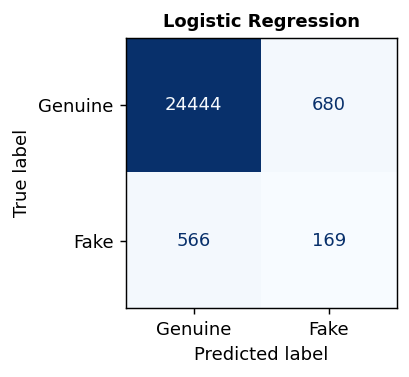

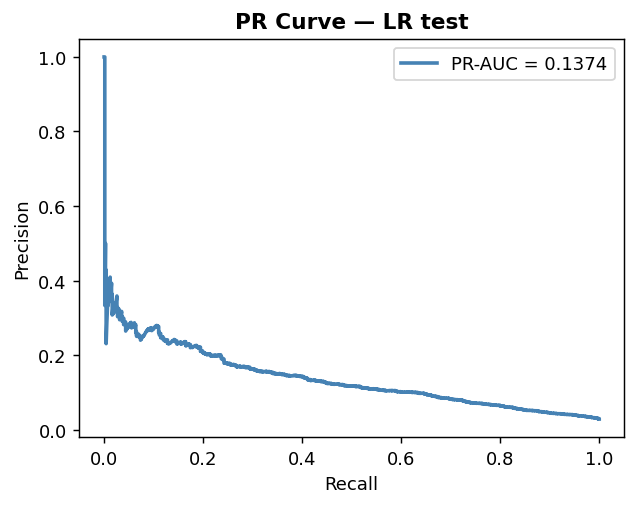


───────────────────────────────────────────────────────
  LightGBM — test  (threshold = 0.077)
───────────────────────────────────────────────────────
  -- Overall --
  Accuracy         : 0.9920
  F1 macro         : 0.9246
  F1 weighted      : 0.9919
  ROC-AUC          : 0.9734
  PR-AUC           : 0.8859
  -- Genuine class --
  Precision        : 0.9946
  Recall           : 0.9972
  F1-score         : 0.9959
  -- Fake class --
  Precision        : 0.8954
  Recall           : 0.8150
  F1-score         : 0.8533

Classification report:
              precision    recall  f1-score   support

 Genuine (0)     0.9946    0.9972    0.9959     25124
    Fake (1)     0.8954    0.8150    0.8533       735

    accuracy                         0.9920     25859
   macro avg     0.9450    0.9061    0.9246     25859
weighted avg     0.9918    0.9920    0.9919     25859



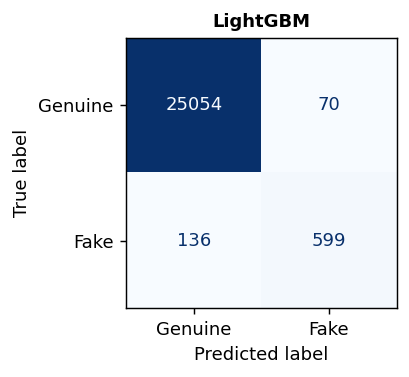

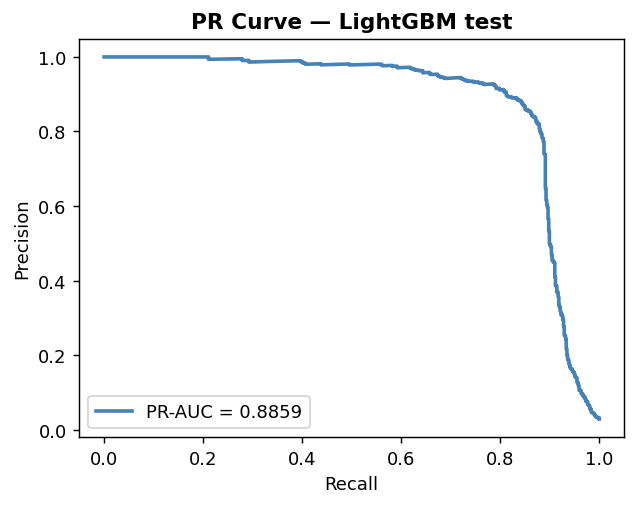

In [15]:
print("\n" + "=" * 60)
print("12. FINAL TEST EVALUATION")
print("=" * 60)

all_results = []

lr_test_proba = best_lr.predict_proba(X_test)[:, 1]
lr_test_pred  = (lr_test_proba >= lr_thresh).astype(int)
metrics_lr    = print_evaluation(
    y_test, lr_test_pred, lr_test_proba,
    "Logistic Regression — test", lr_thresh
)
plot_confusion(y_test, lr_test_pred,
               "Logistic Regression", MODEL_PATH)
plot_pr_curve(y_test, lr_test_proba, "LR test", MODEL_PATH)
all_results.append(metrics_lr)

lgbm_test_proba = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_test_pred  = (lgbm_test_proba >= best_lgbm_thresh).astype(int)
metrics_lgbm    = print_evaluation(
    y_test, lgbm_test_pred, lgbm_test_proba,
    "LightGBM — test", best_lgbm_thresh
)
plot_confusion(y_test, lgbm_test_pred,
               "LightGBM", MODEL_PATH)
plot_pr_curve(y_test, lgbm_test_proba,
              "LightGBM test", MODEL_PATH)
all_results.append(metrics_lgbm)


# ============================================================
# 13. RESULTS TABLE
# ============================================================

In [16]:
print("\n" + "=" * 60)
print("13. RESULTS SUMMARY — EXPERIMENT B2 (TEST SET)")
print("=" * 60)
print("Filtered | TF-IDF + metadata + behavioral features\n")

results_df = pd.DataFrame(all_results).set_index("model")
print(results_df.to_string())
print("\nNote: threshold tuned on validation, applied once on test")

results_df.to_csv(MODEL_PATH + "results_experiment_b2.csv")
print(f"\nSaved: results_experiment_b2.csv")



13. RESULTS SUMMARY — EXPERIMENT B2 (TEST SET)
Filtered | TF-IDF + metadata + behavioral features

                            threshold  accuracy  f1_macro  f1_weighted  roc_auc  pr_auc  precision_gen  recall_gen  f1_gen  precision_fake  recall_fake  f1_fake
model                                                                                                                                                           
Logistic Regression — test      0.880    0.9518    0.5943       0.9535   0.8043  0.1374         0.9774      0.9729  0.9751          0.1991       0.2299   0.2134
LightGBM — test                 0.077    0.9920    0.9246       0.9919   0.9734  0.8859         0.9946      0.9972  0.9959          0.8954       0.8150   0.8533

Note: threshold tuned on validation, applied once on test

Saved: results_experiment_b2.csv


# ============================================================
# 14. LIGHTGBM FEATURE IMPORTANCE
# ============================================================


14. LIGHTGBM FEATURE IMPORTANCE

Top 30 features by importance:
review_interval_cv_r     3291
AFPPR_r                  3278
avg_word_count_r         3231
MCS_r                    3155
WRD_r                    3037
vader_compound_std_r     2960
ACS_r                    2885
MRD_r                    2840
vader_compound_mean_r    2792
ARD_r                    2568
AFTAPP_r                 2496
ASPPR_r                  2390
BRRR_r                   2011
rating_entropy_r         1881
weekend_ratio_r          1786
review_count_r           1686
reviewer_avg_rating_r    1575
EXRR_r                   1509
TRRR_r                   1271
vader_extreme_ratio_r    1107
product_fake_ratio       1104
RPR_r                    1091
max_reviews_per_day_r     998
review_length             986
ERR_r                     975
review_month              887
avg_word_count_p          614
RNR_r                     521
the                       503
BRRR_p                    466

Feature group importance (% of tot

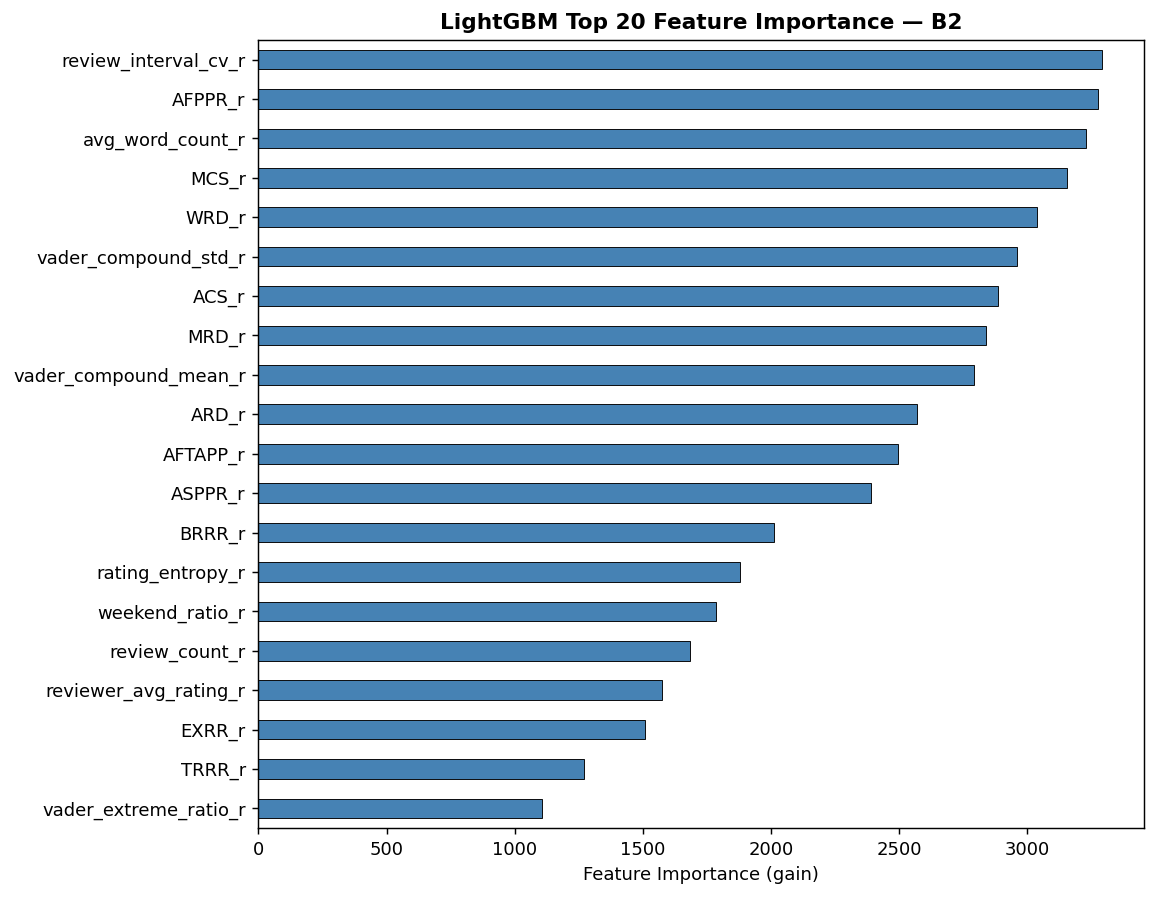

Saved: feature_importance_lgbm_b2.png
Saved: feature_importance.pkl


In [17]:
print("\n" + "=" * 60)
print("14. LIGHTGBM FEATURE IMPORTANCE")
print("=" * 60)

importances  = best_lgbm.feature_importances_
feat_imp     = pd.Series(importances, index=feature_names)
feat_imp_top = feat_imp.sort_values(ascending=False).head(30)

print("\nTop 30 features by importance:")
print(feat_imp_top.to_string())

n_tfidf  = X_tfidf_train.shape[1]
n_meta   = len(META_COLS)
n_behav  = len(behav_cols)
total    = importances.sum()

print(f"\nFeature group importance (% of total):")
print(f"  TF-IDF     : {importances[:n_tfidf].sum()/total*100:.1f}%")
print(f"  Metadata   : {importances[n_tfidf:n_tfidf+n_meta].sum()/total*100:.1f}%")
print(f"  Behavioral : {importances[n_tfidf+n_meta:].sum()/total*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.sort_values(ascending=True).tail(20).plot(
    kind="barh", ax=ax, color="steelblue",
    edgecolor="black", linewidth=0.5
)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("LightGBM Top 20 Feature Importance — B2",
             fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_PATH + "feature_importance_lgbm_b2.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()

joblib.dump(feat_imp, MODEL_PATH + "feature_importance.pkl")
print("Saved: feature_importance_lgbm_b2.png")
print("Saved: feature_importance.pkl")

# ============================================================
# 15. SUMMARY
# ============================================================

In [18]:
print("\n" + "=" * 60)
print("EXPERIMENT B2 COMPLETE")
print("=" * 60)
print(f"""
Dataset  : filtered (threshold > 3)
  Filtered   : {len(df):,} reviews
  Genuine    : {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)
  Fake       : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)

Split    : reused from B1 (70 / 15 / 15 stratified)
  Train      : {len(y_train):,}
  Validation : {len(y_val):,}
  Test       : {len(y_test):,}

Features : {X_train.shape[1]} total
  TF-IDF     : {X_tfidf_train.shape[1]}
  Metadata   : {len(META_COLS)}
  Behavioral : {len(behav_cols)}

Leakage  : all group-level aggregations computed from
           training rows only. Val/test groups receive
           global training mean as fallback.

Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight={scale_pos_weight:.4f}  (LightGBM)

Tuning   : LR grid (3), LGBM grid ({n_combos})
  LR best C        : {lr_gs.best_params_['C']}
  LGBM best params : {best_lgbm_params}
  LR threshold     : {lr_thresh:.4f}
  LGBM threshold   : {best_lgbm_thresh:.4f}

Saved to : {MODEL_PATH}
""")


EXPERIMENT B2 COMPLETE

Dataset  : filtered (threshold > 3)
  Filtered   : 172,389 reviews
  Genuine    : 167,488 (97.2%)
  Fake       : 4,901 (2.8%)
 
Split    : reused from B1 (70 / 15 / 15 stratified)
  Train      : 120,672
  Validation : 25,858
  Test       : 25,859
 
Features : 3061 total
  TF-IDF     : 3000
  Metadata   : 6
  Behavioral : 55
 
Leakage  : all group-level aggregations computed from
           training rows only. Val/test groups receive
           global training mean as fallback.
 
Imbalance: class_weight="balanced"      (LR)
           scale_pos_weight=34.1711  (LightGBM)
 
Tuning   : LR grid (3), LGBM grid (24)
  LR best C        : 0.5
  LGBM best params : {'num_leaves': 128, 'learning_rate': 0.05, 'min_child_samples': 20, 'reg_lambda': 0}
  LR threshold     : 0.8797
  LGBM threshold   : 0.0771
 
Saved to : /content/drive/MyDrive/FakeReviewProject/experiment_b2/models/

